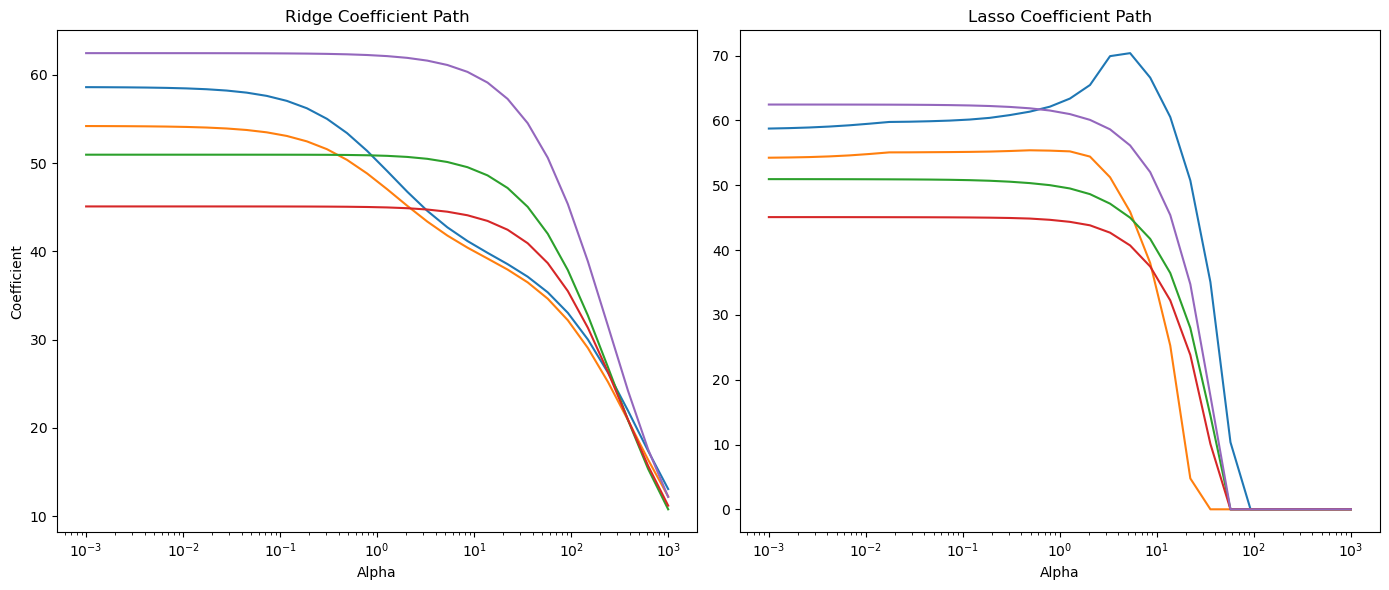


📊 FINAL COMPARISON TABLE
               Model        MAE       RMSE        R²
0  Linear Regression  42.586180  52.919678  0.929280
1        Ridge (α=1)  42.994422  53.301849  0.928255
2     Lasso (best α)  42.269734  52.701597  0.929861

🔍 LASSO FEATURE SELECTION
Optimal Alpha: 1.2689610031679222
Total Features: 20
Eliminated Features (0 coef): 2
Selected Features: [ 0  1  2  3  4  5  6  7  8  9 10 11 13 14 16 17 18 19]


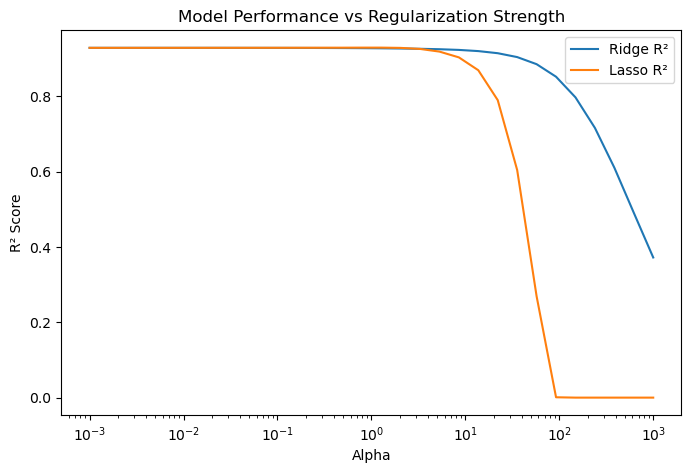


✅ MODELS SAVED SUCCESSFULLY
📁 lasso_best_model.pkl


In [1]:
# ============================================================
#  REGULARIZATION COMPARISON LAB
#  Linear vs Ridge vs Lasso vs ElasticNet
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 1. HIGH-DIMENSIONAL DATASET
# ─────────────────────────────────────────────
X, y = make_regression(
    n_samples=400,
    n_features=20,     # high-dimensional
    noise=25,
    random_state=42
)

# introduce multicollinearity
X[:, 5] = X[:, 0] + np.random.normal(0, 0.1, 400)
X[:, 6] = X[:, 1] + np.random.normal(0, 0.1, 400)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# ─────────────────────────────────────────────
# 2. BASELINE MODEL (Linear Regression)
# ─────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# ─────────────────────────────────────────────
# 3. RIDGE + LASSO ACROSS ALPHAS
# ─────────────────────────────────────────────
alphas = np.logspace(-3, 3, 30)

ridge_coefs = []
lasso_coefs = []

ridge_scores = []
lasso_scores = []

for a in alphas:

    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    ridge_coefs.append(ridge.coef_)
    ridge_scores.append(r2_score(y_test, ridge.predict(X_test)))

    lasso = Lasso(alpha=a, max_iter=5000)
    lasso.fit(X_train, y_train)
    lasso_coefs.append(lasso.coef_)
    lasso_scores.append(r2_score(y_test, lasso.predict(X_test)))

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

# ─────────────────────────────────────────────
# 4. COEFFICIENT PATH PLOT
# ─────────────────────────────────────────────
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
for i in range(5):
    plt.plot(alphas, ridge_coefs[:, i], label=f"Feature {i}")
plt.xscale("log")
plt.title("Ridge Coefficient Path")
plt.xlabel("Alpha")
plt.ylabel("Coefficient")

plt.subplot(1,2,2)
for i in range(5):
    plt.plot(alphas, lasso_coefs[:, i], label=f"Feature {i}")
plt.xscale("log")
plt.title("Lasso Coefficient Path")
plt.xlabel("Alpha")

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 5. BEST LASSO USING CROSS VALIDATION
# ─────────────────────────────────────────────
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)

best_alpha = lasso_cv.alpha_
lasso_best_pred = lasso_cv.predict(X_test)

# features eliminated
zero_features = np.sum(lasso_cv.coef_ == 0)

# ─────────────────────────────────────────────
# 6. FINAL MODELS COMPARISON
# ─────────────────────────────────────────────
models = {
    "Linear Regression": lr_pred,
    "Ridge (α=1)": Ridge(alpha=1).fit(X_train, y_train).predict(X_test),
    "Lasso (best α)": lasso_best_pred
}

results = []

for name, pred in models.items():
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])

df_results = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R²"]
)

print("\n📊 FINAL COMPARISON TABLE")
print(df_results)

# ─────────────────────────────────────────────
# 7. FEATURE SELECTION RESULT (LASSO)
# ─────────────────────────────────────────────
print("\n🔍 LASSO FEATURE SELECTION")
print("Optimal Alpha:", best_alpha)
print("Total Features:", X.shape[1])
print("Eliminated Features (0 coef):", zero_features)

important_features = np.where(lasso_cv.coef_ != 0)[0]
print("Selected Features:", important_features)

# ─────────────────────────────────────────────
# 8. VISUAL COMPARISON OF SCORES
# ─────────────────────────────────────────────
plt.figure(figsize=(8,5))
plt.plot(alphas, ridge_scores, label="Ridge R²")
plt.plot(alphas, lasso_scores, label="Lasso R²")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("R² Score")
plt.title("Model Performance vs Regularization Strength")
plt.legend()
plt.show()

# ─────────────────────────────────────────────
# 9. SAVE MODELS (.PKL FILES)
# ─────────────────────────────────────────────
import pickle


# Best Lasso Model Save (from CV)
with open("lasso_best_model.pkl", "wb") as f:
    pickle.dump(lasso_cv, f)

print("\n✅ MODELS SAVED SUCCESSFULLY")

print("📁 lasso_best_model.pkl")